In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

In [3]:
del_1_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "summary_df_del_1.csv", index_col=0
)
del_2_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "summary_df.csv", index_col=0
)

In [4]:
merged = pd.merge(del_1_df, del_2_df, on="participant_id", suffixes=("_del1", "_del2"))
merged.columns

Index(['participant_id', 'bp_intero_threshold_del1',
       'bp_extero_threshold_del1', 'bp_intero_slope_del1',
       'sn_intero_threshold_del1', 'sn_extero_threshold_del1',
       'sn_intero_slope_del1', 'sn_extero_slope_del1', 'wu_sensitivity_del1',
       'wu_mu_cardiac_prior_del1', 'wu_sigma_cardiac_prior_del1',
       'wu_pi_cardiac_belief_del1', 'bp_intero_threshold_del2',
       'bp_extero_threshold_del2', 'bp_intero_slope_del2',
       'sn_intero_threshold_del2', 'sn_extero_threshold_del2',
       'sn_intero_slope_del2', 'sn_extero_slope_del2', 'wu_sensitivity_del2',
       'wu_mu_cardiac_prior_del2', 'wu_sigma_cardiac_prior_del2',
       'wu_pi_cardiac_belief_del2'],
      dtype='object')

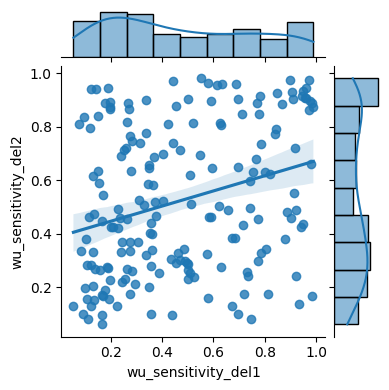

In [5]:
sns.jointplot(
    x=merged.wu_sensitivity_del1, y=merged.wu_sensitivity_del2, kind="reg", height=4
);

In [6]:
pg.corr(
    x=merged.wu_sensitivity_del1.to_numpy(),
    y=merged.wu_sensitivity_del2.to_numpy(),
    method="pearson",
)

,n,r,CI95%,p-val,BF10,power
pearson,187,0.28755,"[0.15, 0.41]",0.000066,246.593,0.980467


In [47]:
pg.ttest(
    x=merged.wu_sensitivity_del1.to_numpy(),
    y=merged.wu_sensitivity_del2.to_numpy(),
    paired=True,
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-2.034589,186,two-sided,0.043312,"[-0.1, -0.0]",0.177605,0.614,0.675881


In [48]:
pg.ttest(
    x=merged.wu_pi_cardiac_belief_del1.to_numpy(),
    y=merged.wu_pi_cardiac_belief_del2.to_numpy(),
    paired=True,
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.602225,186,two-sided,0.547758,"[-0.29, 0.55]",0.056716,0.098,0.120493
